# Notebook de procesamiento de datos twitter15

## Importacion de librerias

In [1]:
import numpy as np
import pandas as pd
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import ast
from datetime import datetime, timezone
import re


In [2]:
BASE_PATH = '../datasets/new_datasets/twitter15/'
TREE_DIR = os.path.join(BASE_PATH, 'tree')
LABEL_PATH = os.path.join(BASE_PATH, 'label.txt')
SOURCE_PATH = os.path.join(BASE_PATH, 'source_tweets.txt')

## Importación de datos

Leer arboles.

In [3]:

rows = []

c = 0
k = 0
q = 0

posts_in_event = set()

for root, dirs, files in os.walk(TREE_DIR):
    print('root:', root)
    for fname in files:

        c += 1
        q -= 1

        source_tree_id = os.path.splitext(fname)[0]

        fpath = os.path.join(root, fname)

        with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
            
            #Primera linea es ROOT->(user_id, tweet_id, delay)
            for line in f:

                k += 1
                q += 1

                line = line.strip()
                if not line or '->' not in line:
                    continue

                left_str, right_str = line.split('->', 1)
                parent = ast.literal_eval(left_str)
                child  = ast.literal_eval(right_str)

                p_uid, p_tid, p_delay = parent
                c_uid, c_tid, c_delay = child

                is_new_post = (p_tid != c_tid)

                posts_in_event.add((str(c_uid), str(c_tid)))

                rows.append({
                    'source_tree_id': source_tree_id,
                    'is_new_post': is_new_post,
                    'parent_user_id': str(p_uid),
                    'parent_tweet_id': str(p_tid),
                    'parent_delay_min': float(p_delay),
                    'child_user_id': str(c_uid),
                    'child_tweet_id': str(c_tid),
                    'child_delay_min': float(c_delay),
                })


df15 = pd.DataFrame(rows, columns=[
    'source_tree_id', 'is_new_post',
    'parent_user_id', 'parent_tweet_id', 'parent_delay_min',
    'child_user_id',  'child_tweet_id',  'child_delay_min'
])

print('C:', c)
print('K:', k)
print('Q:', q)

print('Total number of rows/edges:', len(df15))

for col in ['source_tree_id', 'parent_user_id', 'parent_tweet_id', 'child_user_id', 'child_tweet_id']:
    df15[col] = df15[col].astype('string')


root: ../datasets/new_datasets/twitter15/tree
C: 1490
K: 607289
Q: 605799
Total number of rows/edges: 607289


Leer labels

In [4]:
label_counts = Counter()
label_of = {}

label_map = {
    'non-rumor': 'NR',
    'false': 'FR',
    'true': 'TR',
    'unverified': 'UR',
}


label_counts = Counter()
if os.path.exists(LABEL_PATH):
    with open(LABEL_PATH, 'r', encoding='utf-8', errors='ignore') as f:
        for raw in f:
            s = raw.strip()
            if not s:
                continue
            # expecting "label:tweetid"
            try:
                label_str, sid = s.split(':', 1)
            except ValueError:
                # tolerate malformed lines
                continue
            label_str = label_str.strip().lower()
            sid = sid.strip()

            short = label_map.get(label_str)
            if not short:
                # unknown label -> skip
                continue

            label_of[sid] = short
            label_counts[short] += 1


    print("\nCounts by class:")
    print(f"# of non-rumors (NR):     {label_counts.get('NR', 0)}")
    print(f"# of false-rumors (FR):   {label_counts.get('FR', 0)}")
    print(f"# of true-rumors (TR):    {label_counts.get('TR', 0)}")
    print(f"# of unverified (UR):     {label_counts.get('UR', 0)}")
else:
    print("\n(label.txt not found — skipping label counts)")


Counts by class:
# of non-rumors (NR):     374
# of false-rumors (FR):   370
# of true-rumors (TR):    372
# of unverified (UR):     374


Combinar labels con tweets.

In [5]:
df15['parent_label'] = df15['parent_tweet_id'].map(label_of)
df15.head()

,source_tree_id,is_new_post,parent_user_id,parent_tweet_id,parent_delay_min,child_user_id,child_tweet_id,child_delay_min,parent_label
0,724703995147751424,True,ROOT,ROOT,0.0,15754281,724703995147751424,0.00,NaN
1,724703995147751424,True,15754281,724703995147751424,0.0,27264308,724704170205278208,0.70,UR
2,724703995147751424,True,15754281,724703995147751424,0.0,2411458885,724704234915155968,0.95,UR
3,724703995147751424,True,15754281,724703995147751424,0.0,2748549301,724704415731470336,1.67,UR
4,724703995147751424,True,15754281,724703995147751424,0.0,23147878,724704473172586496,1.90,UR


## Agregar info con Snowflake

In [6]:
def snowflake_to_datetime(snowflake_id: str) -> datetime:
    """
    Convert a Twitter snowflake ID to a UTC datetime object.
    Twitter snowflakes are 64-bit integers where the first 42 bits represent
    the timestamp in milliseconds since Twitter's epoch (2010-11-04 01:42:54 UTC).
    """
    twitter_epoch = 1288834974657  # in milliseconds
    snowflake_int = int(snowflake_id)
    timestamp_ms = (snowflake_int >> 22) + twitter_epoch
    timestamp_s = timestamp_ms / 1000.0
    return datetime.fromtimestamp(timestamp_s, tz=timezone.utc)

In [7]:
snowflake_to_datetime('273182568298450945')

datetime.datetime(2012, 11, 26, 21, 52, 54, 426000, tzinfo=datetime.timezone.utc)

In [8]:
df15['source_datetime'] = df15['source_tree_id'].apply(lambda x: snowflake_to_datetime(int(x)))
df15['child_datetime'] = df15['child_tweet_id'].apply(lambda x: snowflake_to_datetime(int(x)))

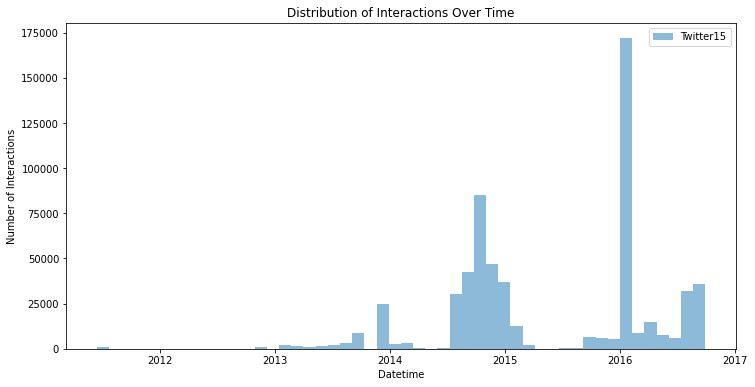

In [9]:
fig = plt.figure(figsize=(12, 6))
plt.hist(df15['source_datetime'], bins=50, alpha=0.5, label='Twitter15')
plt.xlabel('Datetime')
plt.ylabel('Number of Interactions')
plt.title('Distribution of Interactions Over Time')
plt.legend()
plt.show()

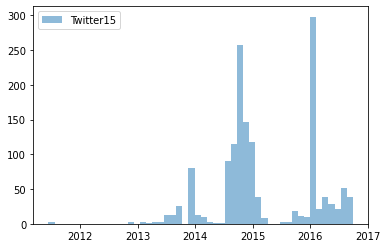

In [10]:
first_time = (df15
              .sort_values('source_datetime')
              .groupby('source_tree_id')['source_datetime']
              .first())
first_time = pd.to_datetime(first_time)

plt.hist(first_time, bins=50, alpha=0.5, label='Twitter15')
plt.legend()


Si una persona a su propio tweet cuenta como engagment? Lol si de hecho kjsd

## Limpiar tweets

In [11]:
text_of = {}
with open(SOURCE_PATH, 'r', encoding='ascii', errors='ignore') as source_tweets:
    source = source_tweets.readlines()
    for i in range(len(source)):
        tid, text = source[i].strip('\n').split('\t', 1)

        text_of[tid] = text
df15['text'] = df15['parent_tweet_id'].map(text_of)
    

In [12]:
df15['text'] = df15['text'].str.replace(r'([.,!?()])', r'\1', regex=True)
df15['text'] = df15['text'].str.replace(r'\s{2,}', ' ', regex=True)
df15['text'] = df15['text'].str.lower()

In [13]:
df15.head()
df15.columns

Index(['source_tree_id', 'is_new_post', 'parent_user_id', 'parent_tweet_id',
       'parent_delay_min', 'child_user_id', 'child_tweet_id',
       'child_delay_min', 'parent_label', 'source_datetime', 'child_datetime',
       'text'],
      dtype='object')

## Ver distribución por labels

In [14]:
df = df15.copy()

In [15]:
df.head()

,source_tree_id,is_new_post,parent_user_id,parent_tweet_id,parent_delay_min,child_user_id,child_tweet_id,child_delay_min,parent_label,source_datetime,child_datetime,text
0,724703995147751424,True,ROOT,ROOT,0.0,15754281,724703995147751424,0.00,NaN,2016-04-25 20:57:51.449000+00:00,2016-04-25 20:57:51.449000+00:00,NaN
1,724703995147751424,True,15754281,724703995147751424,0.0,27264308,724704170205278208,0.70,UR,2016-04-25 20:57:51.449000+00:00,2016-04-25 20:58:33.186000+00:00,"american family association gets 500,000 to si..."
2,724703995147751424,True,15754281,724703995147751424,0.0,2411458885,724704234915155968,0.95,UR,2016-04-25 20:57:51.449000+00:00,2016-04-25 20:58:48.614000+00:00,"american family association gets 500,000 to si..."
3,724703995147751424,True,15754281,724703995147751424,0.0,2748549301,724704415731470336,1.67,UR,2016-04-25 20:57:51.449000+00:00,2016-04-25 20:59:31.724000+00:00,"american family association gets 500,000 to si..."
4,724703995147751424,True,15754281,724703995147751424,0.0,23147878,724704473172586496,1.90,UR,2016-04-25 20:57:51.449000+00:00,2016-04-25 20:59:45.419000+00:00,"american family association gets 500,000 to si..."


In [16]:
df['source_datetime'] = pd.to_datetime(df['source_datetime'], utc=True, errors='coerce')
df['child_datetime']  = pd.to_datetime(df['child_datetime'],  utc=True, errors='coerce')

tree_times = df.groupby('source_tree_id')['source_datetime'].min().rename('tree_start_time')
tree_label = (df.groupby('source_tree_id')['parent_label']
                .agg(lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan)
                .rename('tree_label'))
tree_meta = pd.concat([tree_times, tree_label], axis=1).dropna(subset=['tree_start_time', 'tree_label'])
df = df.merge(tree_meta, on='source_tree_id', how='inner')


/var/folders/s6/qscjwrdd52313z5q26c9176m0000gp/T/ipykernel_8114/3444723728.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda x: x['tree_start_time'].dt.to_period('M').dt.to_timestamp())


<Figure size 432x288 with 0 Axes>

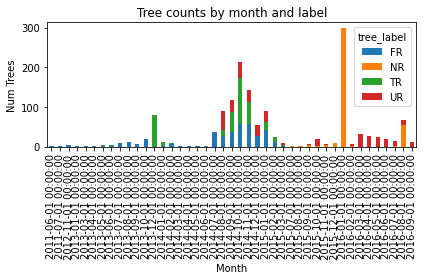

'\n# of non-rumors (NR):     374\n# of false-rumors (FR):   370\n# of true-rumors (TR):    372\n# of unverified (UR):     374\n'

In [17]:
# Label counts by month
month_counts = (tree_meta
                .assign(month=lambda x: x['tree_start_time'].dt.to_period('M').dt.to_timestamp())
                .groupby(['month','tree_label']).size().unstack(fill_value=0))

plt.figure()
month_counts.plot(kind='bar', stacked=True)
plt.title('Tree counts by month and label')
plt.xlabel('Month')
plt.ylabel('Num Trees')
plt.tight_layout()
plt.show()

'''
# of non-rumors (NR):     374
# of false-rumors (FR):   370
# of true-rumors (TR):    372
# of unverified (UR):     374
'''

## Filtrados importantes

In [18]:
# Parte importante, a partir del gráfico para twitter 15 se ve que nos quedamos sin fake romors después de marzo 2015.
df = df.loc[df['source_datetime'] <= '2015-03-01'].copy()

In [19]:
df = df[~df['parent_user_id'].str.upper().eq('ROOT')].copy()


In [20]:
user_counts = df['child_user_id'].value_counts()
one_users = set(user_counts[user_counts <= 1].index)

mask = (~df['child_user_id'].isin(one_users))
df = df[mask].copy()


## Split train val test 80/10/10

In [21]:
def to_utc_naive(s):
    s = pd.to_datetime(s, errors='coerce', utc=True)
    return s.dt.tz_convert('UTC').dt.tz_localize(None)

df['source_datetime'] = to_utc_naive(df['source_datetime'])
df['child_datetime']  = to_utc_naive(df['child_datetime'])

tree_times = df.groupby('source_tree_id')['source_datetime'].min().rename('tree_start_time')
tree_label = (df.groupby('source_tree_id')['parent_label']
                .agg(lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan)
                .rename('tree_label'))
tree_meta = pd.concat([tree_times, tree_label], axis=1).dropna(subset=['tree_start_time','tree_label'])

In [22]:
import numpy as np
import pandas as pd

def split_by_proportions(meta, props=(0.8, 0.1, 0.1), min_each=1):
    """
    Time-ordered split by proportions.
    meta: DataFrame with index=source_tree_id and a 'tree_start_time' column.
    props: target proportions for (train, val, test).
    min_each: minimum number of trees per split (enforced if possible).
    Returns: a pd.Series of splits indexed like meta.
    """
    # sort by time (stable) and compute exact counts
    order = meta.sort_values('tree_start_time')
    n = len(order)
    if n == 0:
        return pd.Series([], dtype=object)

    # normalize props and compute base counts
    p = np.array(props, dtype=float)
    p = p / p.sum()
    base = np.floor(p * n).astype(int)

    # make sure we have at least min_each in each split (if feasible)
    for k in range(3):
        if base[k] < min_each:
            need = min_each - base[k]
            base[k] += need
            # take evenly from others that have > min_each
            for j in np.argsort(-(base - min_each)):
                if j != k and base[j] > min_each and need > 0:
                    take = min(need, base[j] - min_each)
                    base[j] -= take
                    need -= take
            # if still need > 0, remaining will be adjusted below

    # distribute any leftover due to flooring / adjustments
    diff = n - base.sum()
    # positive diff -> add one-by-one to largest-proportion splits (train,val,test)
    # negative diff -> subtract from largest splits (train,val,test) while keeping >= min_each
    if diff != 0:
        order_ix = np.argsort(-p)  # priority by target proportion
        step = 1 if diff > 0 else -1
        while diff != 0:
            for j in order_ix:
                if diff == 0:
                    break
                if step > 0:
                    base[j] += 1
                    diff -= 1
                else:
                    if base[j] > min_each:
                        base[j] -= 1
                        diff += 1

    # final counts
    n_train, n_val, n_test = base.tolist()

    # boundaries (time-ordered)
    labels = (['train'] * n_train) + (['val'] * n_val) + (['test'] * (n - n_train - n_val))
    split_series = pd.Series(labels, index=order.index, dtype=object)

    # reindex to original meta order
    return split_series.reindex(meta.index)


In [23]:
# meta must have one row per tree with 'tree_start_time'
# e.g., meta = tree_meta.copy()
meta = tree_meta.copy()

meta['split'] = split_by_proportions(meta, props=(0.8, 0.1, 0.1), min_each=1)

# Merge back to all rows so each tree stays in one split
df_split = df.merge(meta['split'], left_on='source_tree_id', right_index=True, how='left')

# Sanity checks
assert df_split.groupby('source_tree_id')['split'].nunique().max() == 1
print(meta['split'].value_counts(normalize=True).round(3))
print(meta.groupby(['split','tree_label']).size().unstack(fill_value=0))


split
train    0.800
val      0.100
test     0.099
Name: proportion, dtype: float64
tree_label   FR   TR   UR
split                    
test         49   17   27
train       278  329  143
val          42   22   30


In [24]:
df_split.head()

df = df_split.copy()

# Filtrado de users por interacciones.

In [25]:
all_users = pd.concat([df['child_user_id']], ignore_index=True)
all_users = all_users.dropna()

In [26]:
interaction_counts = all_users.value_counts()

In [27]:
low_users = interaction_counts[interaction_counts <= 1]
n_low = len(low_users)
n_total = interaction_counts.size
print(f"{n_low} of {n_total} users ({n_low/n_total:.2%}) have ≤ 1 interactions.")


0 of 29400 users (0.00%) have ≤ 1 interactions.


29400 of 29400 users (100.00%) have >= 2 interactions.
    K  users_kept  users_kept_%  rows_kept  items_kept
0   2       29400      1.000000      78553        8520
1   3        9161      0.311599      38075        4107
2   4        4081      0.138810      22835        2446
3   5        2124      0.072245      15007        1714
4  10         277      0.009422       3885         835
5  20          32      0.001088        894         412


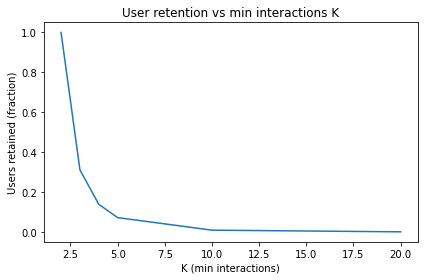

In [28]:
all_users = pd.concat([df['child_user_id']], ignore_index=True).dropna()
ucounts = all_users.value_counts()  # index=user_id, value=#interactions

n_total = ucounts.size
n_le2 = (ucounts >= 2).sum()
print(f"{n_le2} of {n_total} users ({n_le2/n_total:.2%}) have >= 2 interactions.")

def retention_vs_threshold(df, ucounts, thresholds=(2,3,4,5,10,20)):
    rows = []
    for K in thresholds:
        keep_users = set(ucounts[ucounts >= K].index)
        kept = df[df['child_user_id'].isin(keep_users)]
        rows.append({
            'K': K,
            'users_kept': len(keep_users),
            'users_kept_%': len(keep_users)/n_total,
            'rows_kept': len(kept),
            'items_kept': kept['child_tweet_id'].nunique() if 'child_tweet_id' in kept else np.nan
        })
    return pd.DataFrame(rows)

ret_df = retention_vs_threshold(df, ucounts)
print(ret_df)

# (Optional) simple chart
plt.figure()
plt.plot(ret_df['K'], ret_df['users_kept_%'])
plt.title('User retention vs min interactions K')
plt.xlabel('K (min interactions)')
plt.ylabel('Users retained (fraction)')
plt.tight_layout()
plt.show()


In [29]:
dfx = df.dropna(subset=['child_user_id', 'child_datetime']).copy()
dfx['child_datetime'] = pd.to_datetime(dfx['child_datetime'], errors='coerce', utc=True).dt.tz_localize(None)
g = dfx.groupby('child_user_id')['child_datetime']
res = g.agg(first_activity='min', last_activity='max')
sd_ns = g.apply(lambda s: s.view('int64').std(ddof=1))
res['sd_days'] = (sd_ns / (24*3600*1e9)).fillna(0.0)
user_activity = res.reset_index()
user_activity


,child_user_id,first_activity,last_activity,sd_days
0,100003814,2014-08-25 01:23:05.891,2014-12-15 01:43:29.360,79.205972
1,100005598,2014-08-13 01:36:45.721,2014-08-26 12:31:02.308,9.513668
2,10000642,2014-09-29 00:00:48.804,2014-11-24 19:20:15.820,40.167324
3,100008246,2013-06-21 22:22:59.298,2013-10-07 00:20:48.286,75.718279
4,1000164918,2014-08-15 13:20:23.389,2014-11-17 20:37:34.995,66.682720
...,...,...,...,...
29395,999505526,2013-05-21 15:58:57.679,2013-10-07 00:30:12.921,79.875569
29396,999565321,2013-07-01 18:20:45.011,2013-08-10 14:32:01.360,28.171955
29397,999588744,2014-09-13 22:22:32.194,2014-12-16 03:40:31.527,43.857965
29398,99985419,2014-08-19 17:22:19.532,2014-12-15 16:14:24.121,56.846874


In [30]:
a = user_activity[user_activity['child_user_id'] == '99985419']
a.head()

user_activity['child_user_id'].nunique()

29400

In [33]:
print(df.shape)
print(user_activity.shape)
user_activity.head()

(78553, 15)
(29400, 4)


,child_user_id,first_activity,last_activity,sd_days
0,100003814,2014-08-25 01:23:05.891,2014-12-15 01:43:29.360,79.205972
1,100005598,2014-08-13 01:36:45.721,2014-08-26 12:31:02.308,9.513668
2,10000642,2014-09-29 00:00:48.804,2014-11-24 19:20:15.820,40.167324
3,100008246,2013-06-21 22:22:59.298,2013-10-07 00:20:48.286,75.718279
4,1000164918,2014-08-15 13:20:23.389,2014-11-17 20:37:34.995,66.682720


In [37]:
df.to_csv('../data_processing/processed_round2/twitter15_processed.csv', index=False, sep=';')
user_activity.to_csv('../data_processing/processed_round2/twitter15_user_activity.csv', index=False, sep=';')